# No-Show Appointments — EDA

Goal: understand the data and confirm which columns are genuinely known **at booking time** (the only ones we can use as model features, to avoid leakage).

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/KaggleV2-May-2016.csv")
df.shape

(110527, 14)

In [2]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
df.dtypes

PatientId         float64
AppointmentID       int64
Gender                str
ScheduledDay          str
AppointmentDay        str
Age                 int64
Neighbourhood         str
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show               str
dtype: object

In [4]:
df.isna().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [5]:
df["No-show"].value_counts(normalize=True)

No-show
No     0.798067
Yes    0.201933
Name: proportion, dtype: float64

## Booking → appointment gap

`ScheduledDay` and `AppointmentDay` are currently plain text (see `df.dtypes` above), not real dates. We convert them to pandas' `datetime` type so we can do date arithmetic on them (subtract one from the other), which plain strings don't support.

In [6]:
df["ScheduledDay"] = pd.to_datetime(df["ScheduledDay"])
df["AppointmentDay"] = pd.to_datetime(df["AppointmentDay"])

# .dt.date drops the time-of-day part, since ScheduledDay has a timestamp
# but AppointmentDay is always midnight (it only tracks the day of the appointment)
df["wait_days"] = (df["AppointmentDay"].dt.date - df["ScheduledDay"].dt.date).apply(lambda d: d.days)
df["wait_days"].describe()

count    110527.000000
mean         10.183702
std          15.254996
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: wait_days, dtype: float64

A negative `wait_days` would mean the appointment was scheduled *after* it supposedly happened — a data error. Let's check.

In [7]:
(df["wait_days"] < 0).sum()

np.int64(5)

## Does the booking→appointment gap relate to no-show rate?

This is the single most important booking-time feature to check: does waiting longer for an appointment correlate with no-shows? `groupby` splits the data into buckets by a column's value, then we compute the mean no-show rate within each bucket (mean of a 0/1 column = proportion of 1s).

In [8]:
df["no_show_flag"] = (df["No-show"] == "Yes").astype(int)

wait_bucket = pd.cut(df["wait_days"], bins=[-1, 0, 1, 3, 7, 14, 30, 200])
df.groupby(wait_bucket)["no_show_flag"].agg(["mean", "count"])

,mean,count
wait_days,,
"(-1, 0]",0.046469,38563
"(0, 1]",0.213505,5213
"(1, 3]",0.237371,9462
"(3, 7]",0.252027,17510
"(7, 14]",0.304699,12025
"(14, 30]",0.325888,17371
"(30, 200]",0.330025,10378


## SMS_received — is it actually known at booking time?

The dataset doesn't tell us exactly *when* the SMS was sent, only whether one was received (0/1) by appointment time. If reminders are typically sent close to the appointment date (not at booking), then `SMS_received` isn't truly known at the moment of booking — using it as a booking-time feature would be a form of leakage. We can't fully resolve this from the data alone, but we can at least check whether SMS receipt is at all related to `wait_days` (e.g. same-day appointments almost never have time to receive a reminder).

In [9]:
df.groupby(wait_bucket)["SMS_received"].mean()

wait_days
(-1, 0]      0.000000
(0, 1]       0.000000
(1, 3]       0.095751
(3, 7]       0.607767
(7, 14]      0.582453
(14, 30]     0.605607
(30, 200]    0.617653
Name: SMS_received, dtype: float64

## Histogram of wait_days

Visualizing the distribution to sanity-check the bin boundaries chosen above.

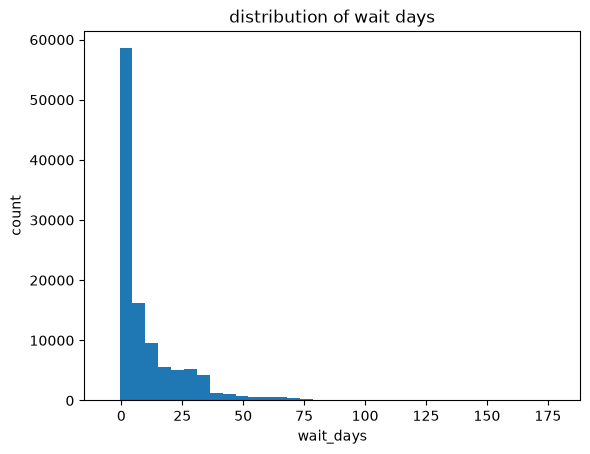

In [10]:
import matplotlib.pyplot as plt
plt.hist(df['wait_days'], bins = 35)
plt.xlabel("wait_days")
plt.ylabel("count")
plt.title("distribution of wait days")
plt.show()

## Age — sanity check

Checking for anomalies (e.g. negative or unrealistic ages) before using Age as a feature.

In [11]:
df['Age'].describe()

count    110527.000000
mean         37.088874
std          23.110205
min          -1.000000
25%          18.000000
50%          37.000000
75%          55.000000
max         115.000000
Name: Age, dtype: float64

In [12]:
(df['Age'] < 0 ).sum()

np.int64(1)

## Age vs no-show rate

In [13]:
age_bucket = pd.cut(df['Age'], bins = [-1, 5, 12, 18,30, 45, 60 , 75, 115])
df.groupby(age_bucket)['no_show_flag'].agg(['mean','count'])

,mean,count
Age,,
"(-1, 5]",0.186259,11731
"(5, 12]",0.228049,9305
"(12, 18]",0.260536,7830
"(18, 30]",0.247122,16765
"(30, 45]",0.213720,21954
"(45, 60]",0.178222,23179
"(60, 75]",0.148643,14370
"(75, 115]",0.161350,5392


## Gender vs no-show rate

In [14]:
df.groupby('Gender')["no_show_flag"].agg(['mean', 'count'])

,mean,count
Gender,,
F,0.203146,71840
M,0.199679,38687


## Binary health/scholarship flags vs no-show rate

In [15]:
cols = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap']
for col in cols:
     print(col)
     print(df.groupby(col)['no_show_flag'].agg(['mean','count']))
     print()

Scholarship
                 mean  count
Scholarship                 
0            0.198072  99666
1            0.237363  10861

Hipertension
                  mean  count
Hipertension                 
0             0.209037  88726
1             0.173020  21801

Diabetes
              mean   count
Diabetes                  
0         0.203628  102584
1         0.180033    7943

Alcoholism
                mean   count
Alcoholism                  
0           0.201946  107167
1           0.201488    3360

Handcap
             mean   count
Handcap                  
0        0.202353  108286
1        0.179236    2042
2        0.202186     183
3        0.230769      13
4        0.333333       3



## Neighbourhood — shape of the column

In [16]:
df['Neighbourhood'].nunique()

81

In [17]:
df['Neighbourhood'].value_counts()

Neighbourhood
JARDIM CAMBURI                 7717
MARIA ORTIZ                    5805
RESISTÊNCIA                    4431
JARDIM DA PENHA                3877
ITARARÉ                        3514
                               ... 
ILHA DO BOI                      35
ILHA DO FRADE                    10
AEROPORTO                         8
ILHAS OCEÂNICAS DE TRINDADE       2
PARQUE INDUSTRIAL                 1
Name: count, Length: 81, dtype: int64

## Neighbourhood vs no-show rate (well-sampled neighborhoods only)

In [18]:
neigh_stats = df.groupby('Neighbourhood')['no_show_flag'].agg(['mean','count'])
neigh_stats = neigh_stats[neigh_stats['count'] >= 500]
neigh_stats.sort_values('mean')

,mean,count
Neighbourhood,,
DO CABRAL,0.157143,560
SANTA MARTHA,0.158416,3131
JARDIM DA PENHA,0.162755,3877
DO QUADRO,0.164900,849
VILA RUBIM,0.165687,851
MATA DA PRAIA,0.170807,644
REPÚBLICA,0.171257,835
CONSOLAÇÃO,0.172238,1376
SANTO ANTÔNIO,0.176256,2746


## Cleaning

Applying the decisions made during EDA above to produce a cleaned dataframe for modeling.

### Drop bad rows (negative wait_days, Age == -1)

In [19]:
df_clean = df[(df['wait_days']>=0) &(df['Age']!=-1)]
df_clean.shape

(110521, 16)

### Drop SMS_received (leaks post-booking info)

In [20]:
df_clean = df_clean.drop(columns = ['SMS_received'])
df_clean.shape

(110521, 15)

### Collapse Handcap to binary

In [21]:
df_clean['Handcap'] = (df_clean['Handcap'] >0).astype(int)
df_clean['Handcap'].value_counts()

Handcap
0    108282
1      2239
Name: count, dtype: int64

### Group rare neighborhoods into 'Other'

In [22]:
neigh_counts = df_clean['Neighbourhood'].value_counts()
rare_neighs = neigh_counts[neigh_counts < 500].index
rare_neighs

Index(['SOLON BORGES', 'PIEDADE', 'SANTA CECÍLIA', 'SANTA LÚCIA',
       'SANTA LUÍZA', 'BARRO VERMELHO', 'DO MOSCOSO', 'MÁRIO CYPRESTE',
       'BOA VISTA', 'COMDUSA', 'DE LOURDES', 'ARIOVALDO FAVALESSA',
       'ANTÔNIO HONÓRIO', 'FRADINHOS', 'ENSEADA DO SUÁ', 'SANTA HELENA',
       'HORTO', 'UNIVERSITÁRIO', 'SEGURANÇA DO LAR', 'NAZARETH',
       'MORADA DE CAMBURI', 'PONTAL DE CAMBURI', 'ILHA DO BOI',
       'ILHA DO FRADE', 'AEROPORTO', 'ILHAS OCEÂNICAS DE TRINDADE',
       'PARQUE INDUSTRIAL'],
      dtype='str', name='Neighbourhood')

In [23]:
df_clean['Neighbourhood'] = df_clean['Neighbourhood'].apply(lambda x : 'Other' if x in rare_neighs else x)
df_clean['Neighbourhood'].value_counts()

Neighbourhood
JARDIM CAMBURI         7717
Other                  6421
MARIA ORTIZ            5805
RESISTÊNCIA            4430
JARDIM DA PENHA        3877
ITARARÉ                3514
CENTRO                 3334
TABUAZEIRO             3131
SANTA MARTHA           3131
JESUS DE NAZARETH      2853
BONFIM                 2773
SANTO ANTÔNIO          2744
SANTO ANDRÉ            2571
CARATOÍRA              2565
JABOUR                 2509
SÃO PEDRO              2448
ILHA DO PRÍNCIPE       2266
NOVA PALESTINA         2264
ANDORINHAS             2262
DA PENHA               2217
ROMÃO                  2214
GURIGICA               2018
SÃO JOSÉ               1977
BELA VISTA             1907
MARUÍPE                1902
FORTE SÃO JOÃO         1889
ILHA DE SANTA MARIA    1885
SÃO CRISTÓVÃO          1836
REDENÇÃO               1553
SÃO BENEDITO           1439
JOANA D´ARC            1427
CRUZAMENTO             1398
CONSOLAÇÃO             1375
SANTA TEREZA           1332
PRAIA DO SUÁ           1288
SANTOS

### Save cleaned data

In [24]:
df_clean.to_csv('../data/processed/no_show_clean.csv', index = False)